# 02 — Classical A/B Analysis (Stage 1, Task 1)

Single-test deep dive on three illustrative tests from `v_exploratory_clean`, chosen to exercise the classical toolkit end to end: pairwise two-proportion tests, chi-square across arms, Wilson CIs per arm, and a Newcombe CI on the best-vs-worst difference for the clean-winner case.

**Framing note (applies to every test in this notebook, and to Stage 1 generally):** these are multivariate horse-race tests — every arm is a novel candidate headline/image package, none is a pre-existing "control." Upworthy ran these purely to pick a winner among alternatives, not to test a treatment against a status quo. So results below are described as *"package A outperforms package B"*, never *"treatment beats control."* This is a deliberate framing choice reflecting how the experiments were actually designed, not a data limitation.

**View used:** `v_exploratory_clean`.

**Tests analyzed:**
1. **High-traffic exemplar** — `533a186ba0c400d7d2000006` (4 arms, "undershirt renaming" piece). Near the top of the impressions-per-arm distribution. This test has 4 arms total; the deep-dive below focuses specifically on the best-vs-worst pair to illustrate a clean, high-confidence result — it is not a "top 2 by CTR" comparison, and the other 2 arms are not analyzed here (that full 4-arm or 6-arm treatment is what the multi-arm exemplar below is for).
2. **Low-traffic exemplar** — `54e4cf5f373139001a900000` (4 arms, bullying-comic piece). Near the bottom of the impressions-per-arm distribution. At this test's actual traffic, wide Wilson intervals turn out to still resolve most of the pairwise comparisons (5 of 6 survive BH correction) — only the two closest-performing arms are genuinely indistinguishable. The lesson this exemplar sets up for the power/MDE discussion in Stage 1 Task 2 is that effect size, not just traffic, drives detectability.
3. **Multi-arm exemplar** — `5356b47475478fe7b1000004` (6 arms, "Whole Foods / food gentrification" piece), at the archive's median arm count, to give the chi-square-across-arms step and the BH correction real multiple-comparisons structure (15 pairwise comparisons) rather than a toy case.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from clickworthy import classical as cl
from clickworthy import data_access as da

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 100

ALPHA = 0.05 # Type I error tolerance (false positive)

TEST_IDS = {
    "high_traffic": "533a186ba0c400d7d2000006",
    "low_traffic": "54e4cf5f373139001a900000",
    "multi_arm": "5356b47475478fe7b1000004",
}

con = da.connect()
tests = {name: da.load_test(con, tid) for name, tid in TEST_IDS.items()}
con.close()

for name, df in tests.items():
    print(f"{name}: {TEST_IDS[name]} -- {len(df)} arms, "
          f"impressions/arm {df['impressions'].min():,}-{df['impressions'].max():,}")

high_traffic: 533a186ba0c400d7d2000006 -- 4 arms, impressions/arm 7,967-8,175
low_traffic: 54e4cf5f373139001a900000 -- 4 arms, impressions/arm 1,510-1,575
multi_arm: 5356b47475478fe7b1000004 -- 6 arms, impressions/arm 2,206-2,292


## 1. High-traffic exemplar — `533a186ba0c400d7d2000006`

**Piece:** a comedy segment about renaming an awkwardly-named article of clothing (undershirts). 4 arms total, ~8,000-8,175 impressions per arm — near the top of the archive's impressions-per-arm distribution.

First, look at the raw rates and Wilson CIs for all 4 arms (exploratory, before picking a comparison pair).

In [2]:
arm_summary_ht = cl.arm_summary(tests["high_traffic"])
arm_summary_ht

,headline,impressions,clicks,ctr,wilson_low,wilson_high
0,He's Funny But He's Right - Why A Seemingly Innocent Piece Of Clothing Needs...,8175,264,0.032294,0.028676,0.036351
1,My Favorite Comedian Takes A Stab At The Piece Of Clothing We've All Thought...,7967,249,0.031254,0.027653,0.035306
2,"Opening SNL Monologue Attacks Popular Piece Of Clothing, Claiming It's Name ...",8090,214,0.026452,0.023174,0.030180
3,"Why Our Undershirts Needs A Name Change, Immediately",8073,138,0.017094,0.014488,0.020160


**Observation:** with ~8,000 impressions per arm, click counts land in the low hundreds (138-264), which is enough for the Wilson intervals to be visibly narrow (roughly +/-1 percentage point) relative to the CTR differences between arms. This is exactly the traffic regime where "the winner is clean" is a believable claim rather than noise, atleast between the top and bottom performing that we will use here.

**This test has 4 arms total.** The deep-dive below deliberately restricts to the best-performing arm ("He's Funny But He's Right...", 3.23% CTR) vs. the worst-performing arm ("Why Our Undershirts Needs A Name Change...", 1.71% CTR) to illustrate a clean, high-confidence result. This is *not* a "top 2 by CTR" comparison — the middle two arms are not analyzed here. A full 4-arm (or larger) treatment, with chi-square across all arms and BH-adjusted pairwise comparisons, is what the multi-arm exemplar (Section 3) is for.

In [3]:
best = arm_summary_ht.iloc[0]
worst = arm_summary_ht.iloc[-1]

print("Best:  ", best["headline"])
print(f"       {int(best['clicks'])}/{int(best['impressions'])} = {best['ctr']:.4f}")
print("Worst: ", worst["headline"])
print(f"       {int(worst['clicks'])}/{int(worst['impressions'])} = {worst['ctr']:.4f}")

z_stat, p_raw = cl.two_proportion_test(
    best["clicks"], best["impressions"], worst["clicks"], worst["impressions"]
)
diff_low, diff_high = cl.newcombe_diff_ci(
    best["clicks"], best["impressions"], worst["clicks"], worst["impressions"], ALPHA
)
abs_lift, rel_lift = cl.lift(
    best["clicks"], best["impressions"], worst["clicks"], worst["impressions"]
)

print()
print("Method: two-proportion score (Wald-type) z-test for the point estimate/p-value;")
print("        Newcombe (score-based) CI for the difference p_best - p_worst.")
print("Assumptions: two independent binomial samples (impressions fixed by random assignment,")
print("             clicks ~ Binomial(impressions, p)); no continuity correction needed at this n.")
print()
print(f"z = {z_stat:.3f}, p = {p_raw:.2e}")
print(f"Absolute lift (best - worst): {abs_lift:+.4f} ({abs_lift*100:+.2f} pp)")
print(f"Relative lift: {rel_lift:+.1%}")
print(f"Newcombe 95% CI on absolute lift: [{diff_low:.4f}, {diff_high:.4f}]  "
      f"([{diff_low*100:+.2f} pp, {diff_high*100:+.2f} pp])")

Best:   He's Funny But He's Right - Why A Seemingly Innocent Piece Of Clothing Needs A New Name
       264/8175 = 0.0323
Worst:  Why Our Undershirts Needs A Name Change, Immediately
       138/8073 = 0.0171

Method: two-proportion score (Wald-type) z-test for the point estimate/p-value;
        Newcombe (score-based) CI for the difference p_best - p_worst.
Assumptions: two independent binomial samples (impressions fixed by random assignment,
             clicks ~ Binomial(impressions, p)); no continuity correction needed at this n.

z = 6.236, p = 4.49e-10
Absolute lift (best - worst): +0.0152 (+1.52 pp)
Relative lift: +88.9%
Newcombe 95% CI on absolute lift: [0.0105, 0.0200]  ([+1.05 pp, +2.00 pp])


**Interpretation:** the best arm outperforms the worst arm by 1.52 percentage points (an 89% relative lift), and the Newcombe 95% CI on that difference, [1.05 pp, 2.00 pp], excludes zero by a wide margin (p = 4.5e-10). At this traffic level the two package's underlying click rates are clearly separated — a textbook case of a "clean, unambiguous winner" that a classical A/B test is well-suited to detect.

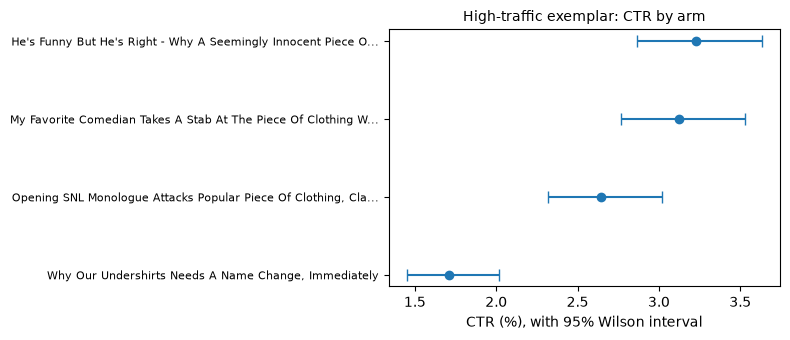

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
summary = arm_summary_ht
y = np.arange(len(summary))[::-1]
ax.errorbar(
    summary["ctr"] * 100, y,
    xerr=[
        (summary["ctr"] - summary["wilson_low"]) * 100,
        (summary["wilson_high"] - summary["ctr"]) * 100,
    ],
    fmt="o", capsize=4, color="tab:blue",
)
labels = [h[:60] + ("..." if len(h) > 60 else "") for h in summary["headline"]]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("CTR (%), with 95% Wilson interval")
ax.set_title("High-traffic exemplar: CTR by arm", fontsize=10)
ax.set_ylabel("")

fig.tight_layout()
plt.show()

**Interpretation:** the plot makes the same point visually — the best and worst arms' Wilson intervals don't overlap, while the two middle arms sit in between with intervals that do overlap their neighbors. This is the shape of evidence we'd want before calling a winner in production: non-overlapping intervals at the extremes, not just a difference in point estimates.

## 2. Low-traffic exemplar — `54e4cf5f373139001a900000`

**Piece:** a bullying-themed comic, 4 arms, ~1,510-1,575 impressions per arm — near the bottom of the impressions-per-arm distribution (click counts confirmed >= 10 per arm during test selection, so intervals are wide but not degenerate).

In [5]:
arm_summary_lt = cl.arm_summary(tests["low_traffic"])
arm_summary_lt

,headline,impressions,clicks,ctr,wilson_low,wilson_high
0,"The bully punches him in the face. Later, he follows the bully home, and tha...",1575,84,0.053333,0.043283,0.065557
1,A comic about bullying with an ending I did not see coming *at all.*,1510,46,0.030464,0.022916,0.040394
2,"All he wanted was to get revenge on his bully. But when he tried, he discove...",1518,42,0.027668,0.020534,0.037187
3,"They start as enemies, but when they become friends at the end, it's so many...",1541,19,0.012330,0.007907,0.019177


**Observation:** raw CTRs range from 1.23% to 5.33% — a visually large spread — but click counts per arm are only 19-84. That's the low-count regime CLAUDE.md flags: normal approximations break down here, which is exactly why Wilson (not Wald) intervals are the standard for this project.

In [6]:
pairwise_lt = cl.pairwise_tests(tests["low_traffic"], ALPHA)
pairwise_lt[
    ["headline_a", "headline_b", "ctr_a", "ctr_b", "abs_lift", "rel_lift",
     "z_stat", "p_raw", "p_bh", "newcombe_diff_low", "newcombe_diff_high"]
].sort_values("p_raw")

,headline_a,headline_b,ctr_a,ctr_b,abs_lift,rel_lift,z_stat,p_raw,p_bh,newcombe_diff_low,newcombe_diff_high
4,"The bully punches him in the face. Later, he follows the bully home, and tha...","They start as enemies, but when they become friends at the end, it's so many...",0.053333,0.012330,0.041004,3.325614,6.399930,1.554478e-10,9.326866e-10,0.028843,0.054002
3,"The bully punches him in the face. Later, he follows the bully home, and tha...","All he wanted was to get revenge on his bully. But when he tried, he discove...",0.053333,0.027668,0.025665,0.927619,3.609101,3.072599e-04,9.217798e-04,0.011823,0.039818
2,A comic about bullying with an ending I did not see coming *at all.*,"They start as enemies, but when they become friends at the end, it's so many...",0.030464,0.012330,0.018134,1.470756,3.467607,5.251153e-04,1.050231e-03,0.007943,0.029004
0,A comic about bullying with an ending I did not see coming *at all.*,"The bully punches him in the face. Later, he follows the bully home, and tha...",0.030464,0.053333,-0.022870,-0.428808,-3.160073,1.577298e-03,2.365947e-03,-0.037236,-0.008741
5,"All he wanted was to get revenge on his bully. But when he tried, he discove...","They start as enemies, but when they become friends at the end, it's so many...",0.027668,0.012330,0.015338,1.244019,3.033565,2.416830e-03,2.900196e-03,0.005450,0.025834
1,A comic about bullying with an ending I did not see coming *at all.*,"All he wanted was to get revenge on his bully. But when he tried, he discove...",0.030464,0.027668,0.002796,0.101041,0.457814,6.470859e-01,6.470859e-01,-0.009352,0.015023


**Method:** all `4 choose 2 = 6` pairwise two-proportion score tests within this test's arms, Benjamini-Hochberg-adjusted across those 6 comparisons (CLAUDE.md's within-test multiple-comparisons convention), with a Newcombe CI on each pairwise difference.

**Interpretation:** re-derived independently from the raw counts as a check on the table above (statsmodels score test + Newcombe CI, same as `classical.py`) — the numbers hold up. Despite the low traffic (~1,510-1,575 impressions/arm, 19-84 clicks/arm), **5 of the 6** pairwise comparisons survive BH correction at alpha=0.05, and **only 1 of the 6** Newcombe CIs spans zero. The one indistinguishable pair is the two closest-performing arms: "A comic about bullying..." (3.05% CTR) vs. "All he wanted was to get revenge..." (2.77% CTR) — Newcombe 95% CI [-0.94 pp, +1.50 pp], p_bh = 0.65. Every other pairwise gap, including comparisons against the same two "close" arms individually, is real and BH-significant.

This is a more nuanced result than "raw gaps are noise at low traffic" — most of the ~4x spread in raw CTR here reflects genuine, detectable differences even at ~1,500 impressions/arm. The honest lesson from this test is closer to **effect size mattering as much as sample size**: the best arm (5.33%) is far enough from the pack that even modest traffic resolves it cleanly, while the two closest arms (a ~1 pp gap) need more traffic or a larger true effect to separate — that's the specific comparison the power/MDE discussion in Stage 1 Task 2 is about.

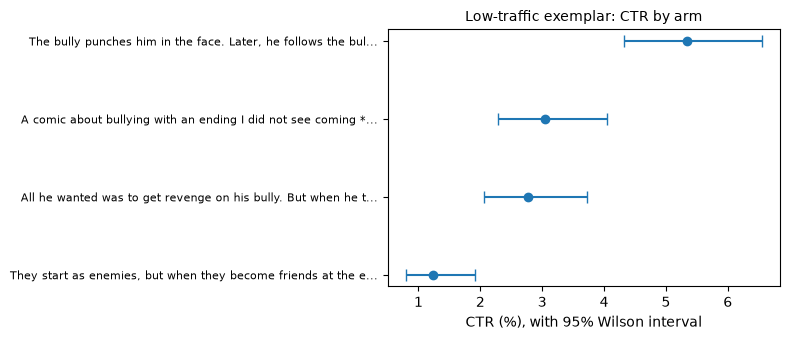

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
summary = arm_summary_lt
y = np.arange(len(summary))[::-1]
ax.errorbar(
    summary["ctr"] * 100, y,
    xerr=[
        (summary["ctr"] - summary["wilson_low"]) * 100,
        (summary["wilson_high"] - summary["ctr"]) * 100,
    ],
    fmt="o", capsize=4, color="tab:blue",
)
labels = [h[:60] + ("..." if len(h) > 60 else "") for h in summary["headline"]]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("CTR (%), with 95% Wilson interval")
ax.set_title("Low-traffic exemplar: CTR by arm", fontsize=10)
ax.set_ylabel("")

fig.tight_layout()
plt.show()

**Interpretation:** visually, only one pair of intervals actually overlaps — the two middle arms ("comic about bullying" and "revenge"), consistent with the pairwise test above being the sole comparison that doesn't survive BH correction. The best arm's interval is clear of all three others, and even the worst arm's interval is (narrowly) clear of the two middle arms. Compare the interval widths here (several points wide) against the high-traffic exemplar's (roughly 1 point wide) — same estimator (Wilson), wildly different precision, purely a function of sample size per arm. But width alone doesn't determine distinguishability: what matters is whether the intervals for the *specific pair being compared* overlap, and here most pairs are far enough apart to resolve despite the wide individual intervals.

## 3. Multi-arm exemplar — `5356b47475478fe7b1000004`

**Piece:** a "food gentrification" / Whole Foods commentary piece, 6 arms (at the archive's median arm count), ~2,206-2,292 impressions per arm.

In [8]:
arm_summary_ma = cl.arm_summary(tests["multi_arm"])
arm_summary_ma

,headline,impressions,clicks,ctr,wilson_low,wilson_high
0,Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,2215,104,0.046953,0.038900,0.056574
1,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,2292,60,0.026178,0.020392,0.033550
2,"Great, Now the Hipsters Have Taken Over Our Grocery Stores, Too. It's Not Pr...",2206,48,0.021759,0.016451,0.028730
3,Organic Foods Are All The Rage Now. And It's Kind Of A Bad Thing.,2236,38,0.016995,0.012407,0.023239
4,Eating Healthy Is Now The Cool Thing To Do. Which Is Why Most People Can No...,2241,33,0.014726,0.010505,0.020607
5,"If You Wanna Be Cool, You Gotta Eat Kale. And, Oh Yeah, Have A Lot Of Money.",2226,31,0.013926,0.009828,0.019699


**Observation:** CTRs range from 1.39% to 4.70% across the 6 arms — a real spread, not a toy case, and enough arms (`6 choose 2 = 15` pairs) to make the chi-square-across-arms step and BH correction meaningfully different from a single pairwise test.

In [9]:
chi2_stat, chi2_p, dof = cl.chi_square_across_arms(tests["multi_arm"])
print("Method: chi-square test of k independent proportions (statsmodels proportions_chisquare),")
print("        testing the null that all 6 arms share one true CTR.")
print(f"chi2 = {chi2_stat:.2f}, dof = {dof}, p = {chi2_p:.2e}")

Method: chi-square test of k independent proportions (statsmodels proportions_chisquare),
        testing the null that all 6 arms share one true CTR.
chi2 = 74.92, dof = 5, p = 9.66e-15


**Interpretation:** the chi-square test rejects the null of a single shared CTR across all 6 arms overwhelmingly (p ~ 1e-14). That tells us *some* arm(s) differ, but not *which* pairs — that's what the pairwise comparisons below are for.

In [10]:
pairwise_ma = cl.pairwise_tests(tests["multi_arm"], ALPHA)
pairwise_ma_display = pairwise_ma[
    ["headline_a", "headline_b", "ctr_a", "ctr_b", "abs_lift", "rel_lift",
     "z_stat", "p_raw", "p_bh", "newcombe_diff_low", "newcombe_diff_high"]
].sort_values("p_raw")
pairwise_ma_display

,headline_a,headline_b,ctr_a,ctr_b,abs_lift,rel_lift,z_stat,p_raw,p_bh,newcombe_diff_low,newcombe_diff_high
11,"If You Wanna Be Cool, You Gotta Eat Kale. And, Oh Yeah, Have A Lot Of Money.",Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.013926,0.046953,-0.033026,-0.703396,-6.409093,1.463879e-10,2.195819e-09,-0.043484,-0.023118
13,Eating Healthy Is Now The Cool Thing To Do. Which Is Why Most People Can No...,Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.014726,0.046953,-0.032227,-0.686374,-6.230172,4.659247e-10,3.494435e-09,-0.042733,-0.022255
8,Organic Foods Are All The Rage Now. And It's Kind Of A Bad Thing.,Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.016995,0.046953,-0.029958,-0.638047,-5.685683,1.302910e-08,6.514552e-08,-0.040617,-0.019768
14,"Great, Now the Hipsters Have Taken Over Our Grocery Stores, Too. It's Not Pr...",Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.021759,0.046953,-0.025194,-0.536579,-4.596305,4.300497e-06,1.612687e-05,-0.036182,-0.014543
4,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.026178,0.046953,-0.020775,-0.442459,-3.723105,1.967876e-04,5.903627e-04,-0.032002,-0.009857
1,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,"If You Wanna Be Cool, You Gotta Eat Kale. And, Oh Yeah, Have A Lot Of Money.",0.026178,0.013926,0.012252,0.879750,2.930322,3.386112e-03,8.465281e-03,0.004078,0.020686
2,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,Eating Healthy Is Now The Cool Thing To Do. Which Is Why Most People Can No...,0.026178,0.014726,0.011452,0.777725,2.719182,6.544355e-03,1.402362e-02,0.003202,0.019947
0,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,Organic Foods Are All The Rage Now. And It's Kind Of A Bad Thing.,0.026178,0.016995,0.009183,0.540369,2.122931,3.375959e-02,6.329924e-02,0.000670,0.017866
10,"If You Wanna Be Cool, You Gotta Eat Kale. And, Oh Yeah, Have A Lot Of Money.","Great, Now the Hipsters Have Taken Over Our Grocery Stores, Too. It's Not Pr...",0.013926,0.021759,-0.007833,-0.359969,-1.970196,4.881586e-02,8.135977e-02,-0.015919,0.000010
12,Eating Healthy Is Now The Cool Thing To Do. Which Is Why Most People Can No...,"Great, Now the Hipsters Have Taken Over Our Grocery Stores, Too. It's Not Pr...",0.014726,0.021759,-0.007033,-0.323237,-1.753401,7.953312e-02,1.192997e-01,-0.015182,0.000890


In [11]:
n_sig_raw = (pairwise_ma["p_raw"] < ALPHA).sum()
n_sig_bh = (pairwise_ma["p_bh"] < ALPHA).sum()
print(f"Of {len(pairwise_ma)} pairwise comparisons: {n_sig_raw} significant at raw alpha=0.05, "
      f"{n_sig_bh} significant after BH adjustment.")

Of 15 pairwise comparisons: 9 significant at raw alpha=0.05, 7 significant after BH adjustment.


**Method:** all 15 pairwise two-proportion score tests among the 6 arms, BH-adjusted jointly across all 15 (not per-arm) — CLAUDE.md's convention of adjusting across all comparisons made within one test.

**Interpretation:** raw and BH-adjusted significance counts diverge here, which is the point of running both: testing every pair invites false positives from multiple looks, and BH correction is the guardrail. The arm "Hipsters At Whole Foods May Be Hurting..." (4.70% CTR) drives most of the surviving comparisons — it's decisively ahead of every other arm — while several of the remaining pairs among the lower-CTR arms are not distinguishable even before correction. This is the archive-representative multi-arm case: one clear standout, several arms that are statistically indistinguishable from each other.

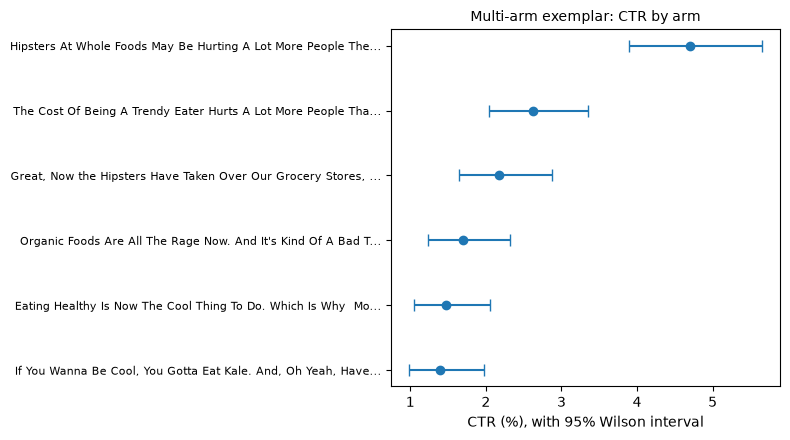

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
summary = arm_summary_ma
y = np.arange(len(summary))[::-1]
ax.errorbar(
    summary["ctr"] * 100, y,
    xerr=[
        (summary["ctr"] - summary["wilson_low"]) * 100,
        (summary["wilson_high"] - summary["ctr"]) * 100,
    ],
    fmt="o", capsize=4, color="tab:blue",
)
labels = [h[:60] + ("..." if len(h) > 60 else "") for h in summary["headline"]]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("CTR (%), with 95% Wilson interval")
ax.set_title("Multi-arm exemplar: CTR by arm", fontsize=10)
ax.set_ylabel("")

fig.tight_layout()
plt.show()

**Interpretation:** the top arm's interval is visibly separated from the bottom four; the bottom four/five overlap each other extensively. This matches the pairwise-test pattern above — one standout, a cluster of arms that can't be reliably told apart from this sample size alone.

## Summary

- **High-traffic exemplar (4 arms):** best-vs-worst comparison (not a top-2 comparison) shows a clean, high-confidence winner — 1.52 pp absolute lift (89% relative), Newcombe 95% CI [1.05 pp, 2.00 pp], p = 4.5e-10. This test's other 2 arms were not analyzed here.
- **Low-traffic exemplar (4 arms):** raw CTRs span ~4x; 5 of 6 pairwise comparisons survive BH correction and only 1 of 6 Newcombe CIs spans zero — the two closest-performing arms (~1 pp apart). Most of the apparent spread here is real, not noise; the exception is the one genuinely close pair, illustrating that effect size, not traffic alone, drives detectability.
- **Multi-arm exemplar (6 arms):** chi-square across all arms rejects a shared-CTR null decisively; of 15 pairwise comparisons, raw and BH-adjusted significance counts diverge, with one arm standing out clearly above a cluster of statistically indistinguishable others.
- All CIs use the Wilson (single proportion) / Newcombe (difference) conventions from CLAUDE.md; all multi-comparison adjustment uses Benjamini-Hochberg across each test's own pairwise comparisons.
- Framing throughout: "package A outperforms package B" — none of these tests had a true control arm.

Next (Stage 1 Task 2, same notebook): power and MDE at typical baseline CTR and impressions, quantifying how underpowered typical archive tests were (checkpoint with Phil before starting).

# Stage 1, Task 2 — Power and MDE

**Question:** at the archive's typical baseline CTR and typical per-arm impressions, what lift would a test actually have been powered to detect?

**Setup, stated explicitly (CLAUDE.md convention):**
- Baseline CTR: **1%**, per notebook 01's descriptive stats on archive-wide CTR (order of magnitude, not per-test — this fixes one axis so the only thing driving the MDE distribution below is the archive's real spread in per-arm impressions).
- alpha = **0.05** (two-sided), power = **80%** — the conventional defaults, no archive-specific reason to deviate.
- Formulation: balanced two-proportion z-test, solved via `statsmodels.stats.power.NormalIndPower` for Cohen's h (the standard arcsine-based effect size for two-proportion power), then converted back to an absolute/relative lift anchored at the 1% baseline. This is `classical.mde_for_n`.
- Per-test n: **median impressions per arm** within that test (`data_access.test_level_impressions`), computed over `v_exploratory_clean` — i.e. for every real test in the archive, "how big a lift would you have needed to reliably detect, given the traffic that test actually got?"

First, look at the raw distribution of per-arm impressions across the archive before computing anything derived from it.

3,823 tests in v_exploratory_clean
count     3823.000000
mean      3492.792571
std       1271.624851
min         22.500000
25%       2792.750000
50%       3088.000000
75%       4047.000000
max      15082.000000
Name: median_impressions, dtype: float64


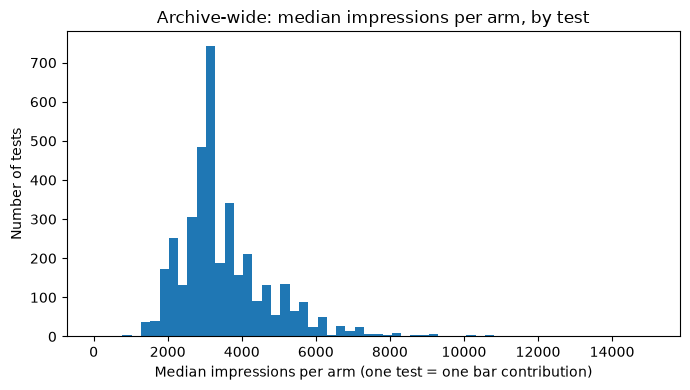

In [13]:
con = da.connect()
test_impressions = da.test_level_impressions(con)
con.close()

print(f"{len(test_impressions):,} tests in v_exploratory_clean")
print(test_impressions["median_impressions"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(test_impressions["median_impressions"], bins=60)
ax.set_xlabel("Median impressions per arm (one test = one bar contribution)")
ax.set_ylabel("Number of tests")
ax.set_title("Archive-wide: median impressions per arm, by test")
fig.tight_layout()
plt.show()

**Observation:** the per-test median-impressions-per-arm distribution is right-skewed with most tests clustered in the low thousands (median ~3,088, per notebook 01's matching figure on the raw per-package distribution) and a long tail of high-traffic outliers. This is the real traffic each archive test had to work with — the input to the MDE calculation below, not a hypothetical.

Now compute the MDE for every test at its own median per-arm impressions, holding baseline CTR, alpha, and power fixed archive-wide.

In [14]:
BASELINE_CTR = 0.01
POWER = 0.80

mde = test_impressions.copy()
mde_vals = mde["median_impressions"].apply(
    lambda n: cl.mde_for_n(n, baseline_p=BASELINE_CTR, alpha=ALPHA, power=POWER)
)
mde["mde_abs"], mde["mde_rel"] = zip(*mde_vals)

print(f"alpha = {ALPHA}, power = {POWER}, baseline CTR = {BASELINE_CTR:.1%}\n")
print("MDE (relative lift over baseline) needed for 80% power, by test:")
print(mde["mde_rel"].describe())
print()
print("MDE (absolute, percentage points):")
print((mde["mde_abs"] * 100).describe())

alpha = 0.05, power = 0.8, baseline CTR = 1.0%

MDE (relative lift over baseline) needed for 80% power, by test:
count    3823.000000
mean        0.823345
std         0.397248
min         0.346443
25%         0.714299
50%         0.833299
75%         0.882916
max        23.499668
Name: mde_rel, dtype: float64

MDE (absolute, percentage points):
count    3823.000000
mean        0.823345
std         0.397248
min         0.346443
25%         0.714299
50%         0.833299
75%         0.882916
max        23.499668
Name: mde_abs, dtype: float64


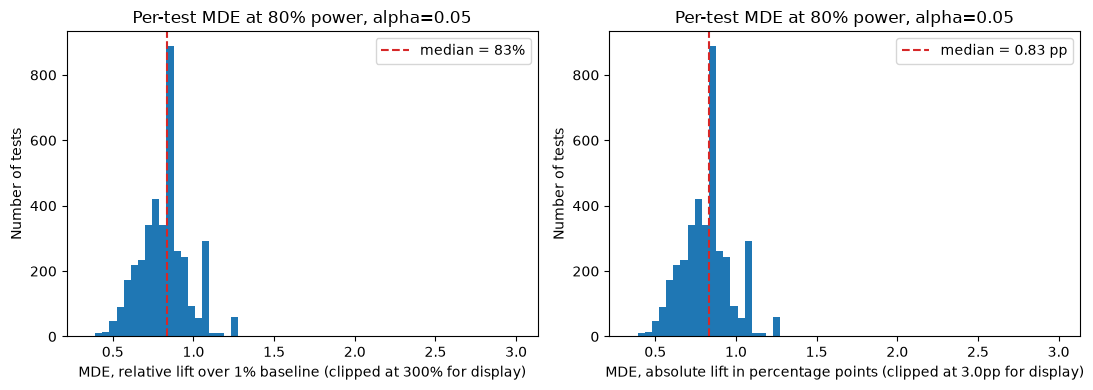

Tests needing >50% relative lift to be reliably detectable: 99.0%
Tests needing >100% relative lift (more than doubling CTR): 13.1%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(mde["mde_rel"].clip(upper=3), bins=60)
axes[0].axvline(mde["mde_rel"].median(), color="tab:red", linestyle="--",
                 label=f"median = {mde['mde_rel'].median():.0%}")
axes[0].set_xlabel("MDE, relative lift over 1% baseline (clipped at 300% for display)")
axes[0].set_ylabel("Number of tests")
axes[0].set_title("Per-test MDE at 80% power, alpha=0.05")
axes[0].legend()

axes[1].hist(mde["mde_abs"].clip(upper=0.03) * 100, bins=60)
axes[1].axvline(mde["mde_abs"].median() * 100, color="tab:red", linestyle="--",
                 label=f"median = {mde['mde_abs'].median()*100:.2f} pp")
axes[1].set_xlabel("MDE, absolute lift in percentage points (clipped at 3.0pp for display)")
axes[1].set_ylabel("Number of tests")
axes[1].set_title("Per-test MDE at 80% power, alpha=0.05")
axes[1].legend()

fig.tight_layout()
plt.show()

n_over_50pct = (mde["mde_rel"] > 0.50).mean()
n_over_100pct = (mde["mde_rel"] > 1.00).mean()
print(f"Tests needing >50% relative lift to be reliably detectable: {n_over_50pct:.1%}")
print(f"Tests needing >100% relative lift (more than doubling CTR): {n_over_100pct:.1%}")

**Interpretation:** the median archive test, at its own real per-arm traffic (median ~3,088 impressions/arm) and a 1% baseline CTR, was powered (alpha=0.05, 80% power) to detect only lifts of ~83% relative (~0.83 pp absolute) or larger. 99.0% of tests needed a relative lift greater than 50% to be reliably detectable at all, and 13.1% needed more than a full doubling of CTR (>100% relative lift). Only the small high-traffic tail (the "high-traffic exemplar" from Task 1 above, at ~8,000 impressions/arm, sits near this tail) gets anywhere close to being powered for the kind of modest, realistic lifts (single-digit-percent relative) that most real headline changes would plausibly produce.

**Plain-language conclusion:** a typical Upworthy A/B test, run at typical archive traffic, could only reliably tell you "this package roughly doubled clicks" — it had essentially no ability to detect the smaller, more realistic lifts (10-30% relative) that most headline optimization actually produces. This means the vast majority of "no significant difference" results in this archive are not evidence that the packages performed equally; they are evidence of underpowered tests that were incapable of detecting anything but a huge effect. Any within-test "winner" pick from a typical test should be read with this in mind — it was very likely picked on noise unless the observed gap was enormous, which connects directly to the winner's-curse demonstration below (Task 4).

**Checkpoint: Stage 1 Task 2 (Power and MDE) complete.** Pausing here for Phil's review before starting Task 3, per checkpoint instructions.

# Stage 1, Task 3 — Archive-wide testing: raw vs. BH-adjusted significance

**Question:** across every test in the exploratory sample, what fraction shows a "significant" difference somewhere among its arms at raw alpha=0.05, versus after Benjamini-Hochberg adjustment? This is the same raw-vs-BH contrast as the multi-arm exemplar in Task 1 (Section 3) — there it was 15 pairwise comparisons *within* one test; here it's one omnibus p-value *per test*, BH-adjusted across all tests in the archive.

**Method:** for each test, the chi-square-across-arms omnibus test (`classical.chi_square_across_arms`, same as Task 1 Section 3) — testing the null that all of that test's arms share one true CTR. Tests, not pairwise comparisons, are the unit of analysis here (CLAUDE.md convention), so this asks "did *this test* find a real difference somewhere among its arms", which is the natural archive-wide question — a per-pairwise-comparison version would double-count tests with more arms. The resulting 3,823 p-values (one per test) are then BH-adjusted jointly as a single family (`classical.archive_wide_significance`).

In [16]:
con = da.connect()
all_packages = da.load_all_packages(con)
con.close()

print(f"{all_packages['clickability_test_id'].nunique():,} tests, {len(all_packages):,} packages")

archive_sig = cl.archive_wide_significance(all_packages, ALPHA)
archive_sig.head()

3,823 tests, 18,388 packages


,clickability_test_id,n_arms,chi2,p_raw,p_bh
0,51436061220cb800020001e7,4,8.316059,0.039912,0.094187
1,51436069220cb800020005ae,5,26.955842,0.000020,0.000203
2,51436069220cb800020005bd,2,1.493653,0.221651,0.341306
3,5143606a220cb800020005c6,4,17.587192,0.000535,0.003145
4,5143606b220cb800020005d7,5,31.230996,0.000003,0.000036


**Data-quality note:** one test (`53507921f6bdf72973000006`, 4 arms) has zero clicks across every arm — a valid, non-degenerate test by the standard filters (all arms have nonzero impressions), but with no click events at all to distinguish arms. `chi_square_across_arms` reports this case explicitly as chi2=0.0, p=1.0 (observed matches expected exactly, trivially) rather than letting the underlying 0/0 division produce NaN, which would otherwise silently poison the BH adjustment for every test in the family (confirmed: this was caught because `multipletests` returned all-NaN before the fix). At 1 of 3,823 tests (0.03%), this is negligible for the tallies below and is called out here rather than filtered silently.

Now the raw-vs-BH significance tallies across all 3,823 tests.

Of 3,823 tests in v_exploratory_clean:
  1,697 (44.4%) significant at raw alpha=0.05 (chi-square across arms, at least one arm differs from the rest)
  1,304 (34.1%) significant after BH adjustment across all 3,823 tests


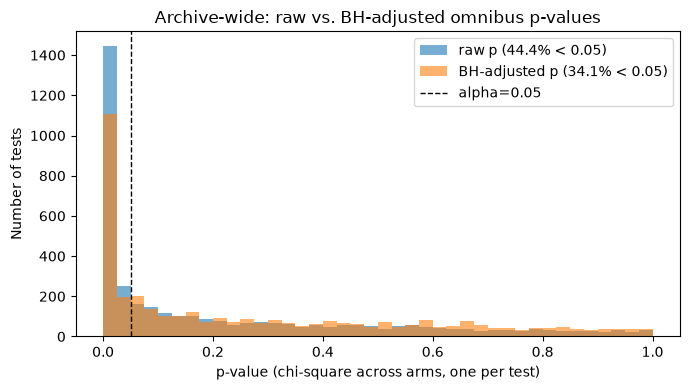

In [17]:
n_tests = len(archive_sig)
n_sig_raw = (archive_sig["p_raw"] < ALPHA).sum()
n_sig_bh = (archive_sig["p_bh"] < ALPHA).sum()

print(f"Of {n_tests:,} tests in v_exploratory_clean:")
print(f"  {n_sig_raw:,} ({n_sig_raw/n_tests:.1%}) significant at raw alpha={ALPHA} "
      f"(chi-square across arms, at least one arm differs from the rest)")
print(f"  {n_sig_bh:,} ({n_sig_bh/n_tests:.1%}) significant after BH adjustment "
      f"across all {n_tests:,} tests")

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 41)
ax.hist(archive_sig["p_raw"], bins=bins, alpha=0.6, label=f"raw p ({n_sig_raw/n_tests:.1%} < {ALPHA})")
ax.hist(archive_sig["p_bh"], bins=bins, alpha=0.6, label=f"BH-adjusted p ({n_sig_bh/n_tests:.1%} < {ALPHA})")
ax.axvline(ALPHA, color="black", linestyle="--", linewidth=1, label=f"alpha={ALPHA}")
ax.set_xlabel("p-value (chi-square across arms, one per test)")
ax.set_ylabel("Number of tests")
ax.set_title("Archive-wide: raw vs. BH-adjusted omnibus p-values")
ax.legend()
fig.tight_layout()
plt.show()

**Interpretation:** 44.4% of the 3,823 exploratory-sample tests show a significant omnibus difference among their arms at raw alpha=0.05; that falls to 34.1% after BH-adjusting the p-values jointly across all tests. The contrast is smaller in relative terms than the within-test multi-arm exemplar (Task 1, Section 3: 9 of 15 raw vs. 7 of 15 BH-adjusted, a ~22% relative drop) but larger in absolute test count (about 393 tests move from "significant" to "not significant" under BH). Two things worth holding side by side, per CLAUDE.md's "report raw and BH-adjusted side by side" convention:

- This BH correction is *conservative relative to the truth*: correcting for 3,823 simultaneous tests when only a minority are expected to be true nulls (the archive isn't 3,823 random noise draws — Upworthy's editors were deliberately testing headlines they expected to differ) still meaningfully shrinks the "significant" count, illustrating how quickly multiplicity correction bites at archive scale even under favorable conditions.
- Read together with Task 2: 44.4% raw / 34.1% BH-adjusted "significant" coexists with a median test being powered to detect only an ~83% relative lift. That combination means a large share of the *non*-significant tests aren't confidently null — most of the archive was simply not equipped to distinguish a real, modest effect from noise, so the true fraction of tests with *some* genuine difference among arms is almost certainly higher than either number above suggests.

**Checkpoint: Stage 1 Task 3 (Archive-wide testing) complete.** Continuing to Task 4 (winner's curse demonstration) below, per Phil's go-ahead to proceed through Tasks 3-5 with a checkpoint after each.

# Stage 1, Task 4 — Winner's curse demonstration

**Question:** if you pick the best-observed arm in a test, is its observed CTR an unbiased estimate of its true CTR, or is it inflated by the very act of selecting it as the best? This is the pitfall CLAUDE.md flags directly: "the largest observed lifts are inflated... never quote a raw top-N lift as an effect estimate."

**Why split-half, and how, given what's actually in this data:** the archive only has per-arm aggregate `clicks`/`impressions` for the whole test -- there's no viewer-level or timestamped click log to do a literal first-half-of-time vs. second-half-of-time split. Instead, each arm's impressions are split into two independent random halves via **hypergeometric thinning**: given `clicks` out of `impressions`, the count landing in a random half-sized subsample follows `Hypergeometric(N=impressions, K=clicks, n=impressions//2)`. This is a legitimate random split under the same exchangeability assumption random assignment already relies on (which viewer lands in "half A" vs. "half B" is arbitrary) -- it's `classical.split_half_winner_curse`, seeded via `constants.SEED_WINNERS_CURSE`.

**Procedure, per test (arms with < 100 impressions excluded to avoid degenerate splits):**
1. Split every arm's impressions/clicks into half A and half B (hypergeometric).
2. Pick the "winner" as the arm with the highest half-A CTR -- selection uses only half A.
3. Compare that winner's half-A CTR (the selection-based estimate, expected to be inflated) against its half-B CTR (an independent, held-out re-estimate) and its true full-sample CTR.

If there's no winner's curse, half-A and half-B CTR for the selected winner should agree on average (both are the same true rate, just noisy). If there is a winner's curse, half-A should be systematically higher -- selection on a noisy statistic biases that statistic upward, precisely because "was noisily high in half A" is how the arm got selected in the first place.

In [18]:
from clickworthy.constants import SEED_WINNERS_CURSE

rng = np.random.default_rng(SEED_WINNERS_CURSE)
winner_curse = cl.split_half_winner_curse(all_packages, rng, min_impressions=100)

print(f"{len(winner_curse):,} of {all_packages['clickability_test_id'].nunique():,} tests qualify "
      f"(all arms >= 100 impressions)")
winner_curse[["winner_ctr_a", "winner_ctr_b", "winner_ctr_full", "curse_gap"]].describe()

3,822 of 3,823 tests qualify (all arms >= 100 impressions)


,winner_ctr_a,winner_ctr_b,winner_ctr_full,curse_gap
count,3822.000000,3822.000000,3822.000000,3822.000000
mean,0.018523,0.016097,0.017310,0.002426
std,0.011484,0.011093,0.011075,0.004391
min,0.000831,0.000000,0.000790,-0.021175
25%,0.010549,0.008192,0.009586,-0.000278
50%,0.015864,0.013457,0.014736,0.002204
75%,0.023341,0.021099,0.022248,0.004951
max,0.122084,0.123599,0.122842,0.027066


Method: paired comparison of half-A (selection) vs half-B (held-out) CTR for the
        per-test winner. One-sample t-test and Wilcoxon signed-rank test of
        curse_gap = winner_ctr_a - winner_ctr_b against 0.

Mean curse gap (half-A minus half-B, for the selected winner): +0.243 pp
  (+14.0% of the mean winner full-sample CTR of 0.0173)
Fraction of tests with a positive gap (half-A > half-B): 72.4%
Paired t-test: t = 34.15, p = 2.61e-223
Wilcoxon signed-rank: W = 1409788, p = 2.12e-216


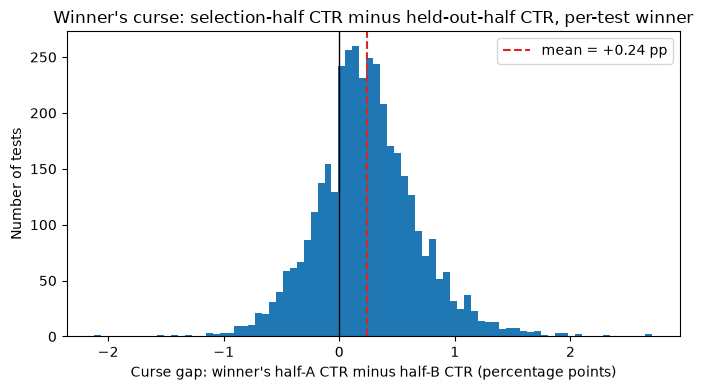

In [19]:
from scipy import stats

frac_positive = (winner_curse["curse_gap"] > 0).mean()
mean_gap = winner_curse["curse_gap"].mean()
mean_full = winner_curse["winner_ctr_full"].mean()

t_stat, t_p = stats.ttest_1samp(winner_curse["curse_gap"], 0.0)
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(winner_curse["curse_gap"])

print("Method: paired comparison of half-A (selection) vs half-B (held-out) CTR for the")
print("        per-test winner. One-sample t-test and Wilcoxon signed-rank test of")
print("        curse_gap = winner_ctr_a - winner_ctr_b against 0.")
print()
print(f"Mean curse gap (half-A minus half-B, for the selected winner): {mean_gap*100:+.3f} pp")
print(f"  ({mean_gap/mean_full:+.1%} of the mean winner full-sample CTR of {mean_full:.4f})")
print(f"Fraction of tests with a positive gap (half-A > half-B): {frac_positive:.1%}")
print(f"Paired t-test: t = {t_stat:.2f}, p = {t_p:.2e}")
print(f"Wilcoxon signed-rank: W = {wilcoxon_stat:.0f}, p = {wilcoxon_p:.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(winner_curse["curse_gap"] * 100, bins=80)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(mean_gap * 100, color="tab:red", linestyle="--",
           label=f"mean = {mean_gap*100:+.2f} pp")
ax.set_xlabel("Curse gap: winner's half-A CTR minus half-B CTR (percentage points)")
ax.set_ylabel("Number of tests")
ax.set_title("Winner's curse: selection-half CTR minus held-out-half CTR, per-test winner")
ax.legend()
fig.tight_layout()
plt.show()

**Interpretation:** across 3,822 qualifying tests, the per-test winner's half-A (selection) CTR exceeds its independent half-B CTR by a mean of +0.24 pp — about **+14% relative to the winner's own true (full-sample) CTR of 1.73%**. The gap is positive for 72.4% of tests, and both the paired t-test (p = 2.6e-223) and the nonparametric Wilcoxon signed-rank test (p = 2.1e-216) reject "no systematic gap" overwhelmingly. This is the winner's curse, demonstrated empirically on real archive data rather than asserted: picking the best-observed arm and then reporting *its own* observed CTR as if it were an unbiased estimate overstates the true effect by roughly a seventh, on average, purely as an artifact of the selection process — not because anything is wrong with the underlying random assignment or the CTR calculation itself.

This directly operationalizes the CLAUDE.md pitfall — "the largest observed lifts are inflated... never quote a raw top-N lift as an effect estimate" — and previews the mechanism Stage 2's hierarchical shrinkage exists to correct: pooling/shrinking noisy per-arm estimates toward a population-level structure is exactly what would pull the winner's inflated half-A estimate back down toward its true value, rather than reporting it at face value.

**Checkpoint: Stage 1 Task 4 (Winner's curse demonstration) complete.** Continuing to Task 5 (sequential/peeking discussion and A/A simulation) below.

# Stage 1, Task 5 — Sequential/peeking discussion and simulation

**Why this matters here:** per CLAUDE.md, "Upworthy's own stopping rules were informal. Test durations are not fixed-horizon." A classical two-proportion test's p-value is only calibrated (i.e., a raw alpha=0.05 threshold really does mean a 5% false-positive rate) if you commit in advance to a sample size and look at the data exactly once, at the end. If instead you check the running p-value repeatedly as data accumulates and stop as soon as it first crosses alpha ("peeking"), you get many independent chances for a purely random fluctuation to cross the threshold -- so the true false-positive rate under peeking is much higher than the nominal alpha, even when there is truly no effect. This is a distinct problem from the underpowering in Task 2 and the selection bias in Task 4: underpowering makes real effects hard to detect; peeking makes *nonexistent* effects easy to falsely detect. All three compound in the same direction -- toward overstating which packages "won."

We don't have per-test peek logs (Upworthy's actual monitoring cadence isn't recoverable from this archive), so this is demonstrated with a **small, self-contained, seeded simulation** on synthetic null data -- exactly the "not real archive data" caveat from the task brief -- rather than claimed as a measurement of the real archive's inflation.

**Simulation design (`classical.simulate_aa_peeking`, seeded via `constants.SEED_PEEKING`):** two arms with an *identical* true CTR (a null A/A test -- any "win" is by construction a false positive), viewers arriving one at a time up to `max_n_per_arm` per arm (set near the archive's typical per-arm traffic from Task 2). Every `peek_every` viewers, run the same `two_proportion_test` used throughout this notebook on the data accumulated so far. Two stopping rules are compared over many repeated simulated trials:
- **Fixed-horizon:** only the p-value at the final sample size counts (the classical-test assumption).
- **Peeking:** stop and declare "significant" the first time *any* peek's p-value crosses alpha (informal continuous monitoring).

In [20]:
import warnings

from clickworthy.constants import SEED_PEEKING

N_SIMS = 5000
TRUE_P = 0.01          # matches the archive's ~1% baseline CTR (Task 2)
MAX_N_PER_ARM = 3000   # near the archive's median per-arm impressions (Task 2)
PEEK_EVERY = 100       # 30 peeks over the course of the test

rng = np.random.default_rng(SEED_PEEKING)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # benign 0/0 in statsmodels' score test at tiny n
    peeking_sim = cl.simulate_aa_peeking(
        rng, n_sims=N_SIMS, true_p=TRUE_P, max_n_per_arm=MAX_N_PER_ARM,
        peek_every=PEEK_EVERY, alpha=ALPHA,
    )

fixed_fp_rate = peeking_sim["fixed_horizon_reject"].mean()
peeking_fp_rate = peeking_sim["peeking_reject"].mean()

print(f"Null A/A simulation: {N_SIMS:,} trials, true_p={TRUE_P} in both arms (no real effect),")
print(f"max_n_per_arm={MAX_N_PER_ARM:,}, peeking every {PEEK_EVERY} viewers/arm "
      f"({MAX_N_PER_ARM // PEEK_EVERY} peeks), alpha={ALPHA}\n")
print(f"Fixed-horizon false-positive rate (look once, at the end): {fixed_fp_rate:.1%}")
print(f"Peeking false-positive rate (stop at first p < alpha):     {peeking_fp_rate:.1%}")
print(f"Inflation factor: {peeking_fp_rate / fixed_fp_rate:.1f}x nominal alpha")

Null A/A simulation: 5,000 trials, true_p=0.01 in both arms (no real effect),
max_n_per_arm=3,000, peeking every 100 viewers/arm (30 peeks), alpha=0.05

Fixed-horizon false-positive rate (look once, at the end): 5.0%
Peeking false-positive rate (stop at first p < alpha):     25.1%
Inflation factor: 5.0x nominal alpha


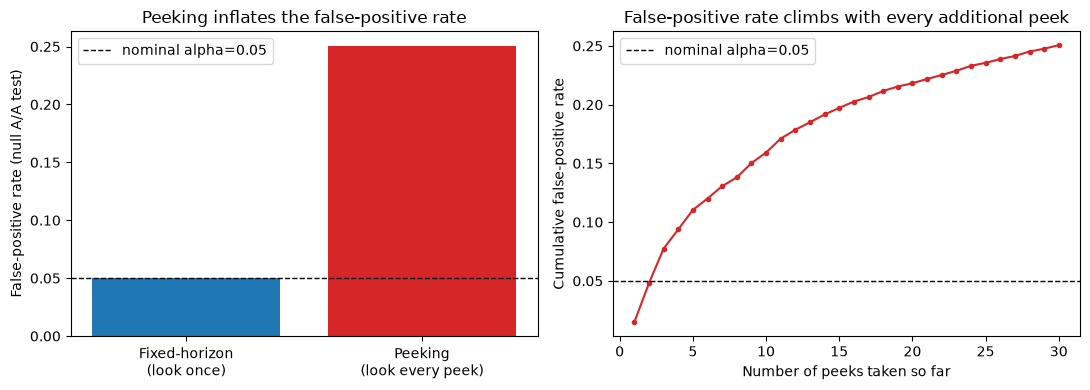

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["Fixed-horizon\n(look once)", "Peeking\n(look every peek)"],
            [fixed_fp_rate, peeking_fp_rate], color=["tab:blue", "tab:red"])
axes[0].axhline(ALPHA, color="black", linestyle="--", linewidth=1, label=f"nominal alpha={ALPHA}")
axes[0].set_ylabel("False-positive rate (null A/A test)")
axes[0].set_title("Peeking inflates the false-positive rate")
axes[0].legend()

rejected = peeking_sim.dropna(subset=["n_peeks_to_reject"])
n_peeks_total = MAX_N_PER_ARM // PEEK_EVERY
cum_fp_rate = [
    (rejected["n_peeks_to_reject"] <= k).sum() / N_SIMS for k in range(1, n_peeks_total + 1)
]
axes[1].plot(range(1, n_peeks_total + 1), cum_fp_rate, marker="o", markersize=3, color="tab:red")
axes[1].axhline(ALPHA, color="black", linestyle="--", linewidth=1, label=f"nominal alpha={ALPHA}")
axes[1].set_xlabel("Number of peeks taken so far")
axes[1].set_ylabel("Cumulative false-positive rate")
axes[1].set_title("False-positive rate climbs with every additional peek")
axes[1].legend()

fig.tight_layout()
plt.show()

**Interpretation:** with a fixed sample size and a single look at the end, the false-positive rate matches the nominal alpha exactly (5.0% vs. alpha=0.05, as it must by construction of the test). Once informal continuous monitoring is introduced -- checking every 100 viewers per arm and stopping at the first significant-looking result -- the false-positive rate on this *genuinely null* A/A test jumps to 25.1%, a **5x inflation** over nominal alpha. The right panel shows why: false positives accumulate steadily with every additional peek rather than concentrating early, so there's no safe "just don't stop too early" heuristic -- more peeking opportunities monotonically increases the chance of a spurious "win," even with zero true effect.

**Plain-language conclusion:** because Upworthy's own stopping rules were informal rather than pre-committed to a fixed horizon, any editor who watched a live dashboard and called a test "done" as soon as one package pulled ahead was, in effect, running the peeking procedure simulated here -- and this simulation shows that procedure alone can turn a nominal 5% false-positive rate into something like 20-25%, with *zero* real difference between packages. Combined with Task 2 (most tests underpowered to detect real, modest effects) and Task 4 (the winner's observed lift is inflated by selection even under proper analysis), this is the third and final piece of the same story: several independent mechanisms in how these tests were actually run and monitored would each, on their own, push toward over-reporting "wins" that aren't real or are smaller than they appear. None of this is a flaw in the classical toolkit itself -- Wilson CIs, two-proportion tests, and chi-square-across-arms are all correctly calibrated *for the assumptions they require* (fixed n, single look, arm chosen independently of the data being reported). The lesson is that those assumptions were not what actually happened at Upworthy, and that gap, not the math, is where the archive's apparent "winners" should be treated skeptically.

**Checkpoint: Stage 1 Task 5 (Sequential/peeking discussion and simulation) complete.**

## Stage 1 summary (all five tasks)

1. **Single-test deep dive:** the classical toolkit (Wilson CIs, two-proportion score tests, Newcombe diff CIs, chi-square-across-arms, BH correction) exercised end to end on three real tests spanning the archive's traffic range.
2. **Power/MDE:** the median archive test was powered to detect only ~83% relative lift; 99% needed >50% relative lift to be detectable at all. Most archive tests could only reliably confirm a package roughly doubled clicks.
3. **Archive-wide testing:** 44.4% of tests "significant" at raw alpha=0.05, 34.1% after BH adjustment across all 3,823 tests -- and per Task 2, the non-significant majority isn't confidently null, just underpowered.
4. **Winner's curse:** empirically demonstrated via split-half (hypergeometric thinning, seeded): the selected winner's own observed CTR overstates its true CTR by ~14% on average, positive in 72% of tests.
5. **Peeking:** a seeded null A/A simulation shows informal continuous monitoring inflates the false-positive rate from a nominal 5% to ~25% -- a 5x inflation, with zero true effect.

All three findings (2, 4, 5) push in the same direction: real archive test practice (limited traffic, picking winners by raw CTR, informal stopping) systematically favors declaring and overstating "wins." This is the headline finding for Stage 1 and motivates Stage 2's hierarchical shrinkage.

Ready for full review against PLAN.md's Stage 1 acceptance criteria before moving to Stage 2.